In [1]:
import os
import json
import yaml
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import sem


def read_config(file_path):
    with open(file_path, 'r') as file:
        return yaml.safe_load(file)

def is_config_valid(config, ref_config, ignore_fields):
    for key, value in ref_config.items():
        if key not in ignore_fields and config.get(key) != value:
#             print(key, config.get(key))
            return False
    return True

def valid_directories(search_path, ref_config, config_ignore_fields):
    valid_dirs = []
    for directory in os.listdir(search_path):
        dir_path = os.path.join(search_path, directory)
        config_path = os.path.join(dir_path, 'config.yaml')
        if os.path.isfile(config_path):
            config = read_config(config_path)
            if (ref_config is None) or is_config_valid(config, ref_config, config_ignore_fields):
                valid_dirs.append(directory)
    return valid_dirs

def read_epochs_data(file_path):
    with open(file_path, 'r') as file:
        return [json.loads(line) for line in file]

def is_run_valid(epoch_data, min_epoch,require_finish_flag=True, finish_flag=None):
    if require_finish_flag:
        return len(epoch_data) >= min_epoch and os.path.isfile(finish_flag)
    else:
        return len(epoch_data) >= min_epoch

def aggregate_results(valid_dirs, min_epoch, search_path, use_test):
    all_results = {}
    all_configs ={}
    for dir_name in valid_dirs:
        dir_path = os.path.join(search_path, dir_name)
        if use_test:
            results_path = os.path.join(dir_path, 'results', 'test_data.json')
            min_epoch = 0
        else:
            results_path = os.path.join(dir_path, 'results', 'epoch_data.json')
        config_path = os.path.join(dir_path, 'config.yaml')
        if os.path.isfile(results_path):
            epoch_data = read_epochs_data(results_path)
            if is_run_valid(epoch_data, 
                            min_epoch, 
                            require_finish_flag=True, 
                            finish_flag = os.path.join(dir_path,'run_finished')):
#             if  os.path.isfile(os.path.join(dir_path,'run_finished')):
                dir_results = {}
                for epoch in epoch_data:
                    for key, value in epoch.items():
                        if key not in dir_results:
                            dir_results[key] = []
                        dir_results[key].append(value)
                all_results[dir_name] = dir_results
                all_configs[dir_name] = read_config(config_path)
    return all_results, all_configs

# Main function
def analyze_runs(ref_config_path, search_path, config_ignore_fields, min_epoch, use_test):
    ref_config = read_config(ref_config_path) if ref_config_path is not None else None
    valid_dirs = valid_directories(search_path, ref_config, config_ignore_fields)
#     print(valid_dirs)
    return aggregate_results(valid_dirs, min_epoch, search_path, use_test)

def mean_k_last_result(result_dicts,key,k_last, as_dict=False):
    results = {} if as_dict else []
    for run_name, result_dict in result_dicts.items():
        if key in result_dict.keys():
            this_result = np.mean(result_dict[key][-k_last:])
            if as_dict:
                results[run_name] = this_result
            else:
                results.append(this_result)
        else:
            print(f'warning, no such a field in run name:{run_name}')
    return results


def mean_std_of_not_too_low(x,rtol=0.1):
    ref = np.max(x)
    ii = x>ref*(1-rtol)
    if not np.all(ii):
        print('WARNING, some runs discarded:', ii)
    return np.mean(x[ii]), np.std(x[ii]), np.sum(ii), sem(x[ii])

In [2]:
#rev2: changed datasets related to FMNIST for ones with vertical move 
#(results still reflect the horizontal move only, but on datasets that contain both)

In [3]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def add_inset_with_symbols(ax, width="30%", height="30%", loc=1, 
                           styles=None, titles = None, 
                           bbox=(0.5, 0.5, 0.5, 0.5)):
    """
    Add an inset to the given axis with symbols and their meanings.

    Parameters:
    ax (matplotlib.axes.Axes): The axis to add the inset to.
    width (str): Width of the inset as a percentage of the parent axis.
    height (str): Height of the inset as a percentage of the parent axis.
    loc (int): Location code for the inset (1=upper right, 2=upper left, etc.).
    """
    # Define inset axis
    inset_ax = inset_axes(ax, width=width, height=height, bbox_to_anchor=bbox, loc=loc,
                         bbox_transform=ax.transAxes)

    # Add the symbols and their meanings to the inset

    for style, title in zip(styles, titles):
        inset_ax.plot([], [], style, label=title)

    # Hide the inset axis ticks and labels
    inset_ax.set_xticks([])
    inset_ax.set_yticks([])
    inset_ax.legend(loc='center')

In [4]:
ds_LUT = {'20240623':{'ds':'MNIST', 'dist':'D1'},}
#           '20240707':{'ds':'MNIST', 'dist':'D2'},
#           '20240801':{'ds':'FMNIST', 'dist':'D1'}, #change in rev2
#           '20240728':{'ds':'FMNIST', 'dist':'D2'}, #change in rev2
#           '20240703':{'ds':'KMNIST', 'dist':'D1'},
#           '20240705':{'ds':'KMNIST', 'dist':'D2'},
#          }

In [5]:
frames_LUT ={('MNIST','D1'): 0.882,
             ('MNIST','D2'): 0.664,
             ('FMNIST','D1'): 0.813,
             ('FMNIST','D2'): 0.725,
             ('KMNIST','D1'): 0.830,
             ('KMNIST','D2'): 0.666,
            }

In [6]:
min_epoch = 0
use_test = True
search_path = '../wexac_saved_runs/'

ref_config_paths = {'full_table':'../wexac_saved_runs/NMNIST_seeds_ver2__911248//config.yaml',
                      }

config_ignore_fields_s = {'full_table':['json_log', 'run_name', 'seed', 'ds_args_n_samples','config_file',
                        'json_test_data', 'check_job_recovery','eb_ds_path', 'job_id']
                          }
                        
dfs = {}

for this_mode in ref_config_paths:
    dfs[this_mode] = {}
    ref_config_path =ref_config_paths[this_mode]
    config_ignore_fields =config_ignore_fields_s[this_mode]
    result_dicts, config_dicts = analyze_runs(ref_config_path, search_path, config_ignore_fields, min_epoch, 
                                                  use_test=use_test)
    full_dict = {k:{**config_dicts[k],**result_dicts[k]} for k in result_dicts}
    dfs[this_mode] = pd.DataFrame(full_dict).transpose()
    dfs[this_mode]['test_acc'] = dfs[this_mode]['test_acc'].map(lambda x: x[0])
    print(f'found {len(full_dict)} runs for mode {this_mode}')

found 35 runs for mode full_table


In [7]:
def squeeze_dict(d):
    return d[[k for k in d.keys()][0]]

In [8]:
df = squeeze_dict(dfs)

In [9]:
n_samples_s = np.sort(df['ds_args_n_samples'].unique())

In [10]:
dd = {}
for n_samples in n_samples_s:
        dd[(n_samples )] = \
        df[df['ds_args_n_samples'] == n_samples].\
        aggregate({'test_acc':[lambda x: mean_std_of_not_too_low(x)[0],
                               lambda x: mean_std_of_not_too_low(x)[1],
                               lambda x: mean_std_of_not_too_low(x)[2],
                                lambda x: mean_std_of_not_too_low(x)[3]]+ ['median','mean','std','sem']})

In [11]:
dd

{16:           test_acc
 <lambda>  0.921600
 <lambda>  0.000738
 <lambda>  5.000000
 <lambda>  0.000369
 median    0.922100
 mean      0.921600
 std       0.000825
 sem       0.000369,
 32:           test_acc
 <lambda>  0.976560
 <lambda>  0.000589
 <lambda>  5.000000
 <lambda>  0.000294
 median    0.976400
 mean      0.976560
 std       0.000658
 sem       0.000294,
 48:           test_acc
 <lambda>  0.985640
 <lambda>  0.000989
 <lambda>  5.000000
 <lambda>  0.000495
 median    0.985700
 mean      0.985640
 std       0.001106
 sem       0.000495,
 64:           test_acc
 <lambda>  0.989280
 <lambda>  0.000705
 <lambda>  5.000000
 <lambda>  0.000353
 median    0.989500
 mean      0.989280
 std       0.000789
 sem       0.000353,
 96:           test_acc
 <lambda>  0.991680
 <lambda>  0.000248
 <lambda>  5.000000
 <lambda>  0.000124
 median    0.991800
 mean      0.991680
 std       0.000277
 sem       0.000124,
 128:           test_acc
 <lambda>  0.991800
 <lambda>  0.000253
 <lambda> 

In [12]:
df_prep = []

for n_samples in n_samples_s:
    df_prep.append([n_samples,
                    f'{dd[(n_samples)].iloc[0,0]:.3f}',
                    f'{dd[(n_samples)].iloc[1,0]:.3f}',
                    f'{dd[(n_samples)].iloc[2,0]:.3f}',
                    f'{dd[(n_samples)].iloc[3,0]:.3f}'])

In [13]:
dfsum = pd.DataFrame(df_prep, columns = ['n_events' ,'AccMean','AccStd','AccCnt','AccSem'])

In [14]:
dfsum = dfsum.sort_values(by=['n_events'])

In [15]:
dfsum

,n_events,AccMean,AccStd,AccCnt,AccSem
0,16,0.922,0.001,5.000,0.000
1,32,0.977,0.001,5.000,0.000
2,48,0.986,0.001,5.000,0.000
3,64,0.989,0.001,5.000,0.000
4,96,0.992,0.000,5.000,0.000
5,128,0.992,0.000,5.000,0.000
6,256,0.993,0.000,5.000,0.000


In [16]:
import pandas as pd

def df_to_latex_table(df: pd.DataFrame, new_column_names: dict = None, column_formats: dict = None, default_format: str = ".3f") -> str:
    """
    Convert a pandas DataFrame to a LaTeX table string with optional column renaming, formatting, and multi-line headers.
    
    Parameters:
        df (pd.DataFrame): The DataFrame to convert.
        new_column_names (dict, optional): A dictionary to rename columns. 
                                           Format: {'old_name': 'new_name'}.
        column_formats (dict, optional): A dictionary specifying format for columns.
                                         Format: {'column_name': 'format_specifier'}.
                                         Example: {'A': '.2f', 'B': 'd'}.
        default_format (str, optional): Default formatting for numeric values. Defaults to '.3f'.
                                           
    Returns:
        str: Full LaTeX code for the table.
    """
    def try_convert_to_number(value):
        """Try to convert a value to a number if it looks like one."""
        try:
            return float(value) if '.' in str(value) else int(value)
        except ValueError:
            return value

    def format_header(header):
        """Format a column header to split long text into multiple lines using \makecell."""
        return "\\makecell{" + " \\\\ ".join(header.split()) + "}"

    # Rename columns if new_column_names is provided
    if new_column_names:
        df = df.rename(columns=new_column_names)
    
    # Apply formatting to columns if column_formats is provided
    formatted_df = df.copy()
    for col in formatted_df.columns:
        if column_formats and col in column_formats:
            fmt = column_formats[col]
        else:
            fmt = default_format  # Use default format for unspecified columns
        
        formatted_df[col] = formatted_df[col].apply(
            lambda x: f"{try_convert_to_number(x):{fmt}}" 
                      if pd.notnull(x) and isinstance(try_convert_to_number(x), (int, float)) 
                      else x
        )
    
    # Start the LaTeX table
    latex_code = "\\begin{table}[ht]\n\\centering\n"
    latex_code += "\\begin{tabular}{" + " | ".join(["c"] * len(formatted_df.columns)) + "}\n"
    latex_code += "\\hline\n"
    
    # Add column headers with multi-line formatting
    formatted_headers = [format_header(header) for header in formatted_df.columns]
    latex_code += " & ".join(formatted_headers) + " \\\\\n"
    latex_code += "\\hline\n"
    
    # Add rows
    for _, row in formatted_df.iterrows():
        latex_code += " & ".join(map(str, row)) + " \\\\\n"
        latex_code += "\\hline\n"
    
    # End the LaTeX table
    latex_code += "\\end{tabular}\n"
    latex_code += "\\caption{Your table caption here.}\n"
    latex_code += "\\label{tab:your_label_here}\n"
    latex_code += "\\end{table}"
    
    return latex_code


In [17]:
print(
    df_to_latex_table(dfsum[[ 'n_events', 'AccCnt','AccMean','AccStd','AccSem' ]],
                     column_formats={'AccCnt':'.0f'})
)

\begin{table}[ht]
\centering
\begin{tabular}{c | c | c | c | c}
\hline
\makecell{n_events} & \makecell{AccCnt} & \makecell{AccMean} & \makecell{AccStd} & \makecell{AccSem} \\
\hline
16.000 & 5 & 0.922 & 0.001 & 0.000 \\
\hline
32.000 & 5 & 0.977 & 0.001 & 0.000 \\
\hline
48.000 & 5 & 0.986 & 0.001 & 0.000 \\
\hline
64.000 & 5 & 0.989 & 0.001 & 0.000 \\
\hline
96.000 & 5 & 0.992 & 0.000 & 0.000 \\
\hline
128.000 & 5 & 0.992 & 0.000 & 0.000 \\
\hline
256.000 & 5 & 0.993 & 0.000 & 0.000 \\
\hline
\end{tabular}
\caption{Your table caption here.}
\label{tab:your_label_here}
\end{table}


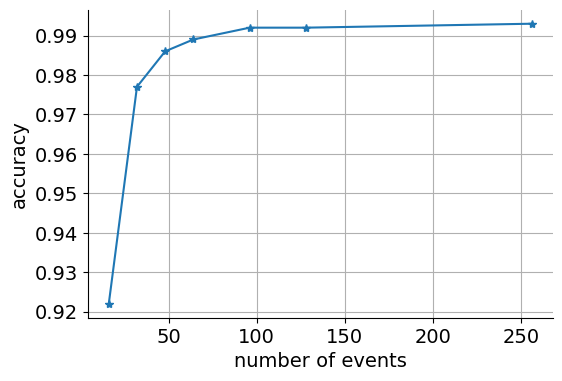

In [22]:
plt.figure(2,figsize=(6,4))
plt.rcParams.update({'font.size': 14})
plt.plot(dfsum['n_events'].to_numpy(),dfsum['AccMean'].astype(float),'*-')
plt.grid()
plt.xlabel('number of events')
plt.ylabel('accuracy') 
plt.gca().spines[['right', 'top']].set_visible(False)
_ = plt.yticks(np.linspace(0.92,0.99,8))
plt.savefig('figS1panelC.svg',format='svg')


In [23]:
dfsum

,n_events,AccMean,AccStd,AccCnt,AccSem
0,16,0.922,0.001,5.000,0.000
1,32,0.977,0.001,5.000,0.000
2,48,0.986,0.001,5.000,0.000
3,64,0.989,0.001,5.000,0.000
4,96,0.992,0.000,5.000,0.000
5,128,0.992,0.000,5.000,0.000
6,256,0.993,0.000,5.000,0.000


In [24]:
# dfsum.to_csv(f'figS1panelC.csv')
